In [21]:
import pandas as pd
import numpy as np
import zipfile
import os
import pandas as pd
import numpy as np
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('project_dataset_housing.csv')

In [11]:
# Preprocessing
BINARY_COLS = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]

FURNISHING_ORDER = {"unfurnished":  0, "semi-furnished": 1, "furnished":  2}


def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in BINARY_COLS:
        df[col] = (df[col].str.strip().str.lower() == "yes").astype(int)
    df["furnishingstatus"] = (df["furnishingstatus"].str.strip().str.lower().map(FURNISHING_ORDER))
    return df


# training and testing split
df_clean = preprocess(df)
df_clean.sample(10)

X = df_clean.drop("price", axis=1)
y = df_clean["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [17]:
#model
lambdas = np.logspace(-3, 6, 100)

model = RidgeCV(alphas=lambdas, cv=5)
model.fit(X_train, y_train)

print(f"Best λ :{model.alpha_:.4f}")

#test mse

print("\nŷ = f(x):")
print(f"  Intercept : {model.intercept_:,.2f}")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature:<22}: {coef:>12,.2f}")

y_pred   = model.predict(X_test)
test_mse = np.mean((y_test - y_pred) ** 2)
print(f"\nTest MSE  : {test_mse:,.2f}")
print(f"Test RMSE : {np.sqrt(test_mse):,.2f}")

Best λ : 5.3367

ŷ = f(x):
  Intercept : -87,295.27
  area                  :       241.82
  bedrooms              :    94,018.71
  bathrooms             : 1,034,367.22
  stories               :   413,625.63
  mainroad              :   336,941.54
  guestroom             :   230,018.42
  basement              :   390,311.19
  hotwaterheating       :   534,210.65
  airconditioning       :   735,032.77
  parking               :   232,446.92
  prefarea              :   587,353.99
  furnishingstatus      :   215,968.28

Test MSE  : 1,785,218,597,196.13
Test RMSE : 1,336,120.73


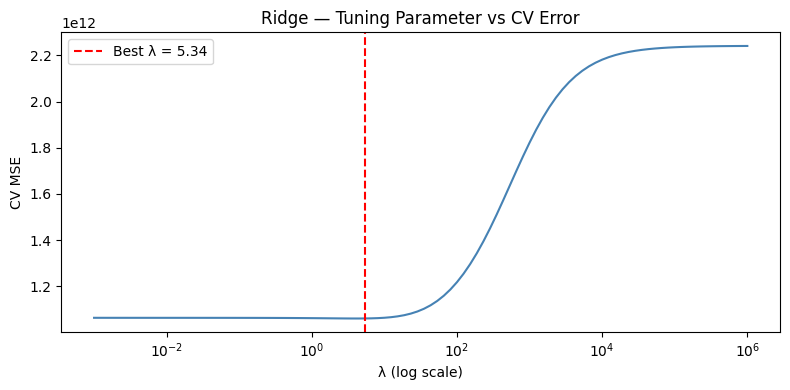

In [15]:
#λ vs CV error plot

from sklearn.model_selection import cross_val_score
cv_errors = [-cross_val_score(RidgeCV(alphas=[lam]), X_train, y_train,
              cv=5, scoring="neg_mean_squared_error").mean() for lam in lambdas]

plt.figure(figsize=(8, 4))
plt.semilogx(lambdas, cv_errors, color="steelblue")
plt.axvline(model.alpha_, color="red", linestyle="--", label=f"Best λ = {model.alpha_:.2f}")
plt.xlabel("λ (log scale)"); plt.ylabel("CV MSE")
plt.title("Ridge — Tuning Parameter vs CV Error")
plt.legend(); plt.tight_layout()
plt.savefig("ridge_cv_plot.png", dpi=150); plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=cca14342-032d-4c69-8309-45231d7b44b5' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>